# Необходимо реализовать механизм вычисления метки подынтервалу (под-окну) (при перекрытии окон при разбиении) на основе ответов модели
 1) Суммарное агрегирование для подынтервала
 2) Среднее арифметическое вероятности в зависимости от дистанции (от центра окна). Так как свёрточная сеть лучше работает на серидине окна (проблемы с краями) 

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-05-05 23:49:33.714902: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.npz'
data = load_angles(data_path, ['phi_0_original', 'phi_1_original'], time_column='time_years',convert_to_xy=True)

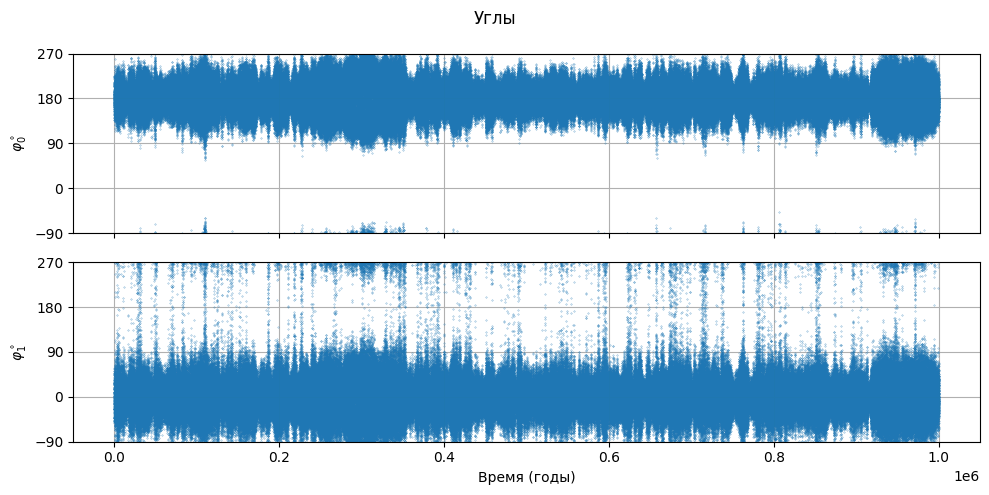

In [4]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы')

In [5]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.5
)

In [6]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')
# probs = predict_multiplet(windows['angle_windows'], model)
# classes = [predict_classes_from_proba(p) for p in probs]

W0000 00:00:1778006977.983959  365291 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
probs = predict_multiplet(windows['angle_windows'], model)
# classes = [predict_classes_from_proba(p) for p in probs]

In [9]:
# probs[0].shape

In [10]:
classes = [predict_classes_from_proba(p) for p in probs]

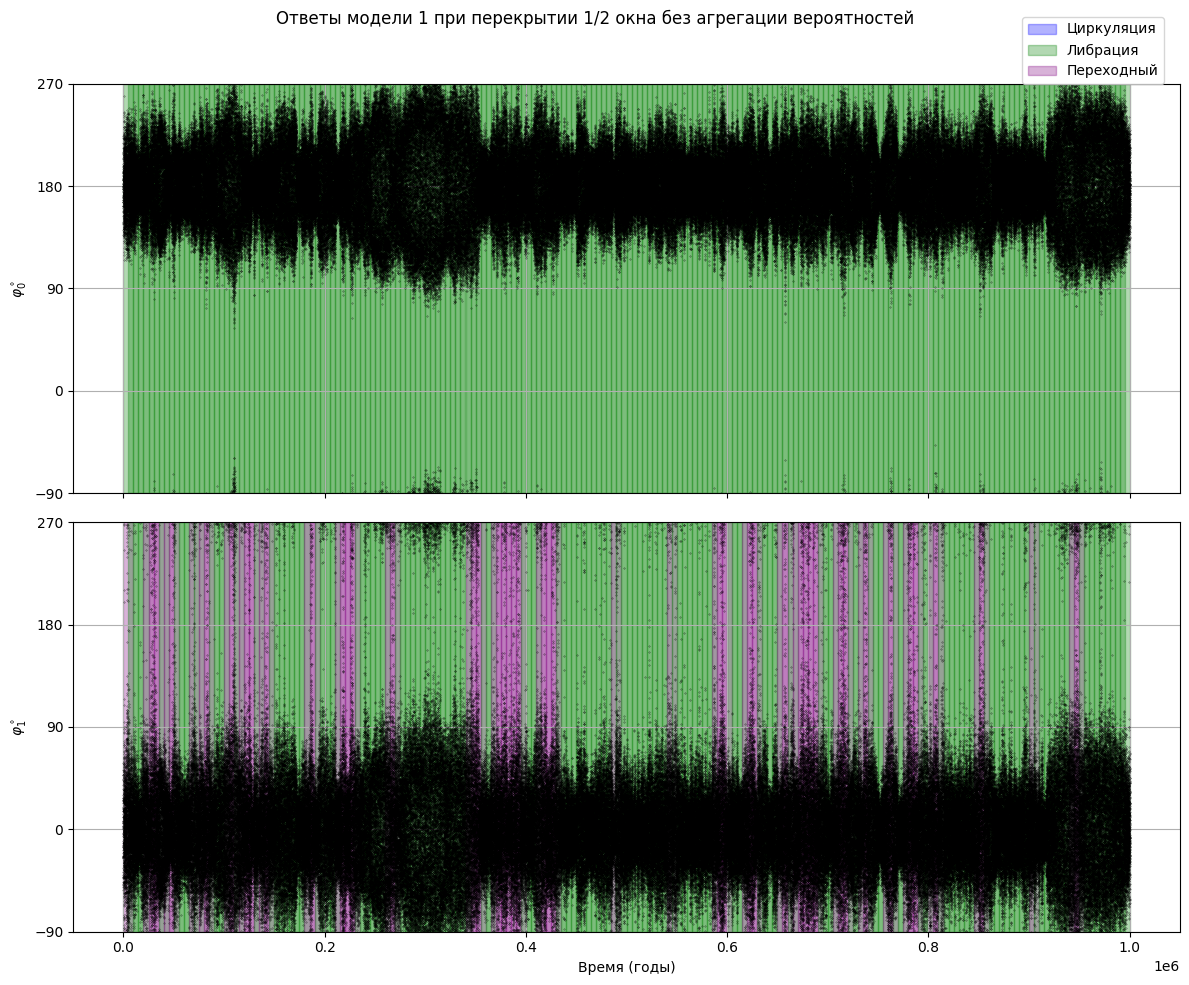

In [11]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1 при перекрытии 1/2 окна без агрегации вероятностей',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.,
    fig_width=12.,
    row_height=5.,
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

На самый первый подынтервал $1$ и последний $N$ приходится по одному прогнозу от модели. На все остальные по 2. То есть:
\begin{equation}
\begin{split}
& F_{p_n} \in [f_N,f_{N+1}], F_{p_n} \ne F_{p_1} \lor F_{p_N}, \\
& F_{p_1} \in [f_1], \\
& F_{p_N} \in [f_N], \\
\end{split}
\end{equation}

где $F_{p_n}$ $-$ подынтервал, $f_N$ $-$ окно разбиения. При перекрытии окон разбиения в $1/2$ окна, получается $2n-1$ окон, если исходный ряд разбивался на $n$ окон (без перекрытий). Подынтервалов, соответственно $2n$, из которых $2$, получат по одному прогнозу, а $2(n-1)$ $-$ по $2$ прогноза.

In [12]:
from src.agregate import average_overlapping_probs #грубые вероятности

In [13]:
sub_data = average_overlapping_probs(probs, windows['window_bounds'])

In [14]:
# sub_data

In [15]:
# sub_data['probs']

In [16]:
# sub_data['probs'][0].shape # для первого угла мультиплета агрегированные для 2,3,4,...,n-2,n-1 окна

In [17]:
# probs[0].shape

In [18]:
# sub_data['probs'][1].shape # для второго угла мультиплета

In [19]:
# print(sub_data['probs'][0][0]) #[0][0] [0][1]    нелевое
# print(sub_data['probs'][0][1]) #[0][1] [0][2]    #первое
# print(sub_data['probs'][0][2]) #[0][2] [0][3]    второе
# print(sub_data['probs'][0][3]) #[0][3] [0][4]    третье
# print(sub_data['probs'][0][4]) #[0][4] [0][5]    четвертое
# print(sub_data['probs'][0][5]) #[0][5] [0][6]    пятое

In [20]:
# print(probs[0][0]) 
# print(probs[0][1])
# print(probs[0][2])
# print(probs[0][3])
# print(probs[0][4])
# print(probs[0][5])
# print(probs[0][6])

In [21]:
# print(probs[0][0]) # нелевое
# print((probs[0][0]+probs[0][1])/2.) #первое
# print((probs[0][1]+probs[0][2])/2.) #второе
# print((probs[0][2]+probs[0][3])/2.) #третье
# print((probs[0][3]+probs[0][4])/2.) #четвертое
# print((probs[0][4]+probs[0][5])/2.) #пятое

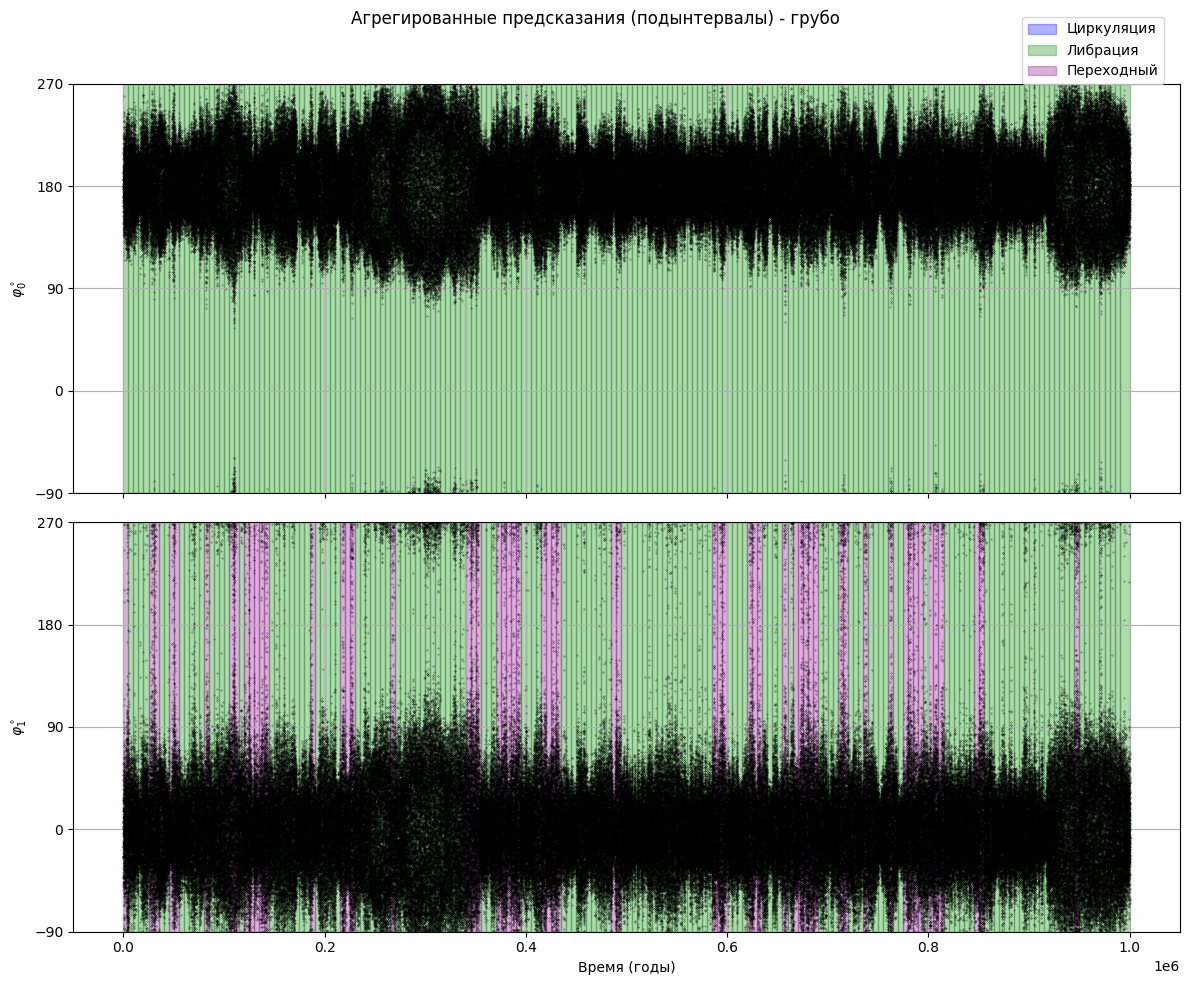

In [22]:
#та же модель 
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=sub_data['bounds'],
    class_labels_list=sub_data['classes'],
    title='Агрегированные предсказания (подынтервалы) - грубо',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.,
    fig_width=12.,
    row_height=5.,
    
)

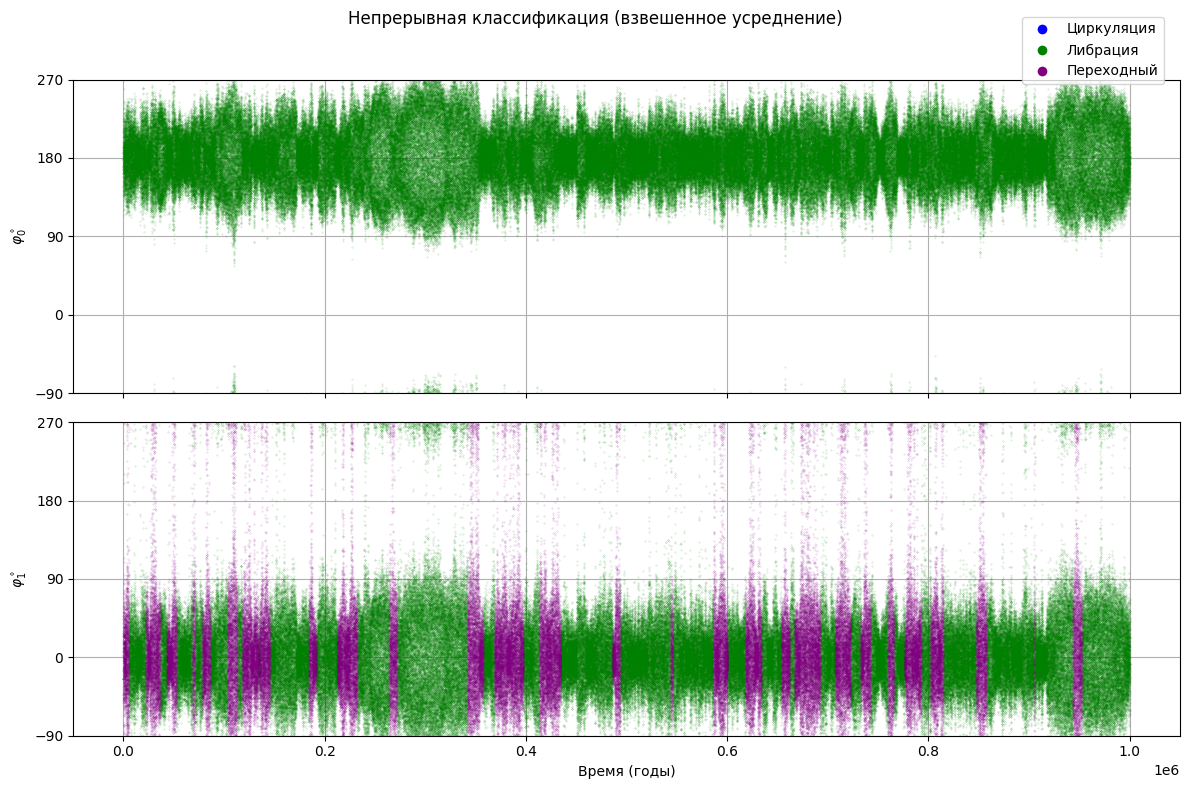

In [28]:
from src.agregate import continuous_probabilities #Непрерывные вероятности
from src.visual import plot_continuous_classes # график
#раскраска точки под результирующую вероятность (как треугольное весовое усреднение)
continuous_=continuous_probabilities(probs, windows['window_bounds'])
plot_continuous_classes(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    class_labels_list=continuous_['classes'],
    title='Непрерывная классификация (взвешенное усреднение)',
    alpha=0.3,
    fig_width=12.,
    row_height= 4.,
    # save_path=""

)#Первый и последний подынтервал - просто вероятности окон, без учёта весов